In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import fetch_california_housing  # 替代波士顿数据集
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# 设置中文显示
plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False

In [2]:
# 加载加州住房数据
housing = fetch_california_housing()
df = pd.DataFrame(housing.data, columns=housing.feature_names)
df['target'] = housing.target

# 查看数据结构
print("数据形状:", df.shape)
print("\n前5行数据:")
print(df.head())
print("\n数据统计描述:")
print(df.describe())
print("\n特征说明:")
print(housing.DESCR)

数据形状: (20640, 9)

前5行数据:
   MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0  8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88   
1  8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86   
2  7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85   
3  5.6431      52.0  5.817352   1.073059       558.0  2.547945     37.85   
4  3.8462      52.0  6.281853   1.081081       565.0  2.181467     37.85   

   Longitude  target  
0    -122.23   4.526  
1    -122.22   3.585  
2    -122.24   3.521  
3    -122.25   3.413  
4    -122.25   3.422  

数据统计描述:
             MedInc      HouseAge      AveRooms     AveBedrms    Population  \
count  20640.000000  20640.000000  20640.000000  20640.000000  20640.000000   
mean       3.870671     28.639486      5.429000      1.096675   1425.476744   
std        1.899822     12.585558      2.474173      0.473911   1132.462122   
min        0.499900      1.000000      0.846154      0.

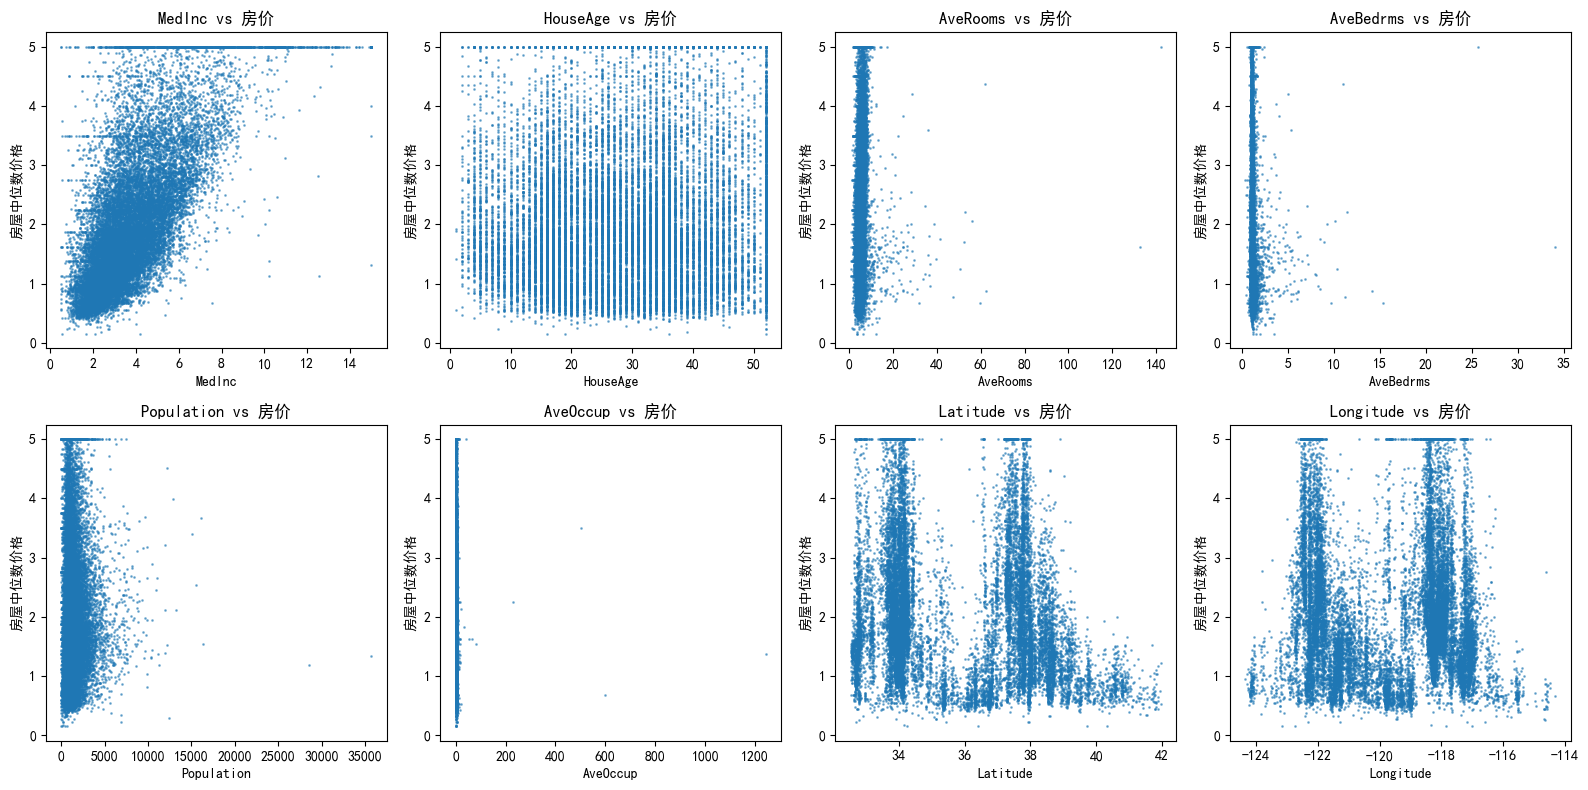

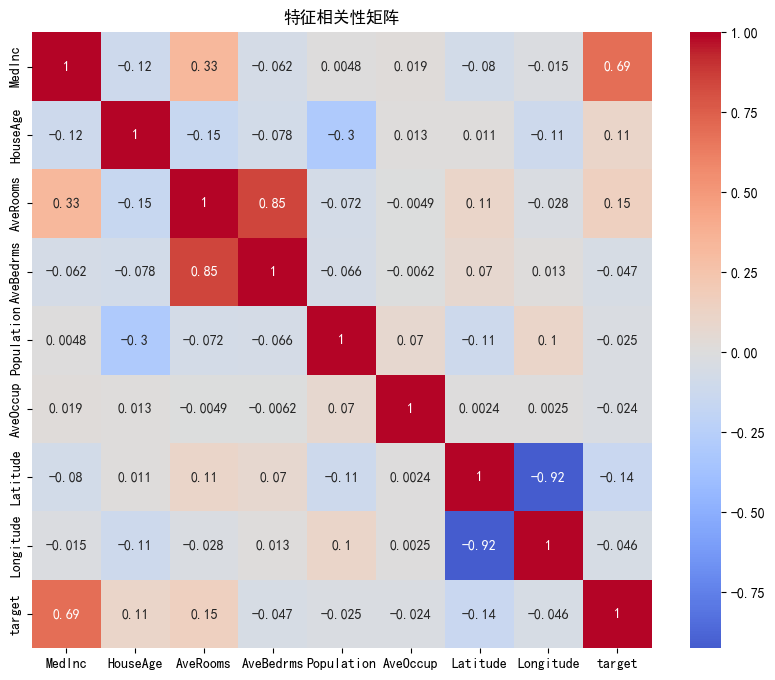

In [3]:
# 设置图形
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

# 绘制每个特征与目标变量的关系
for i, feature in enumerate(housing.feature_names):
    axes[i].scatter(df[feature], df['target'], alpha=0.5, s=1)
    axes[i].set_xlabel(feature)
    axes[i].set_ylabel('房屋中位数价格')
    axes[i].set_title(f'{feature} vs 房价')

plt.tight_layout()
plt.show()

# 相关性热图
plt.figure(figsize=(10, 8))
correlation_matrix = df.corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0)
plt.title('特征相关性矩阵')
plt.show()

In [4]:
# 划分特征和目标变量
X = df.drop('target', axis=1)
y = df['target']

# 划分训练集和测试集（80%训练，20%测试）
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"训练集大小: {X_train.shape}")
print(f"测试集大小: {X_test.shape}")

# 特征标准化（对线性回归很重要）
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

训练集大小: (16512, 8)
测试集大小: (4128, 8)


In [5]:
# 创建并训练线性回归模型
model = LinearRegression()
model.fit(X_train_scaled, y_train)

# 模型系数
print("\n模型系数:")
for feature, coef in zip(housing.feature_names, model.coef_):
    print(f"{feature:>10}: {coef:.4f}")
print(f"截距: {model.intercept_:.4f}")


模型系数:
    MedInc: 0.8544
  HouseAge: 0.1225
  AveRooms: -0.2944
 AveBedrms: 0.3393
Population: -0.0023
  AveOccup: -0.0408
  Latitude: -0.8969
 Longitude: -0.8698
截距: 2.0719


In [6]:
# 预测
y_train_pred = model.predict(X_train_scaled)
y_test_pred = model.predict(X_test_scaled)

# 评估指标
def evaluate_model(y_true, y_pred, dataset_name):
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    
    print(f"\n{dataset_name}集评估结果:")
    print(f"均方误差 (MSE): {mse:.4f}")
    print(f"均方根误差 (RMSE): {rmse:.4f}")
    print(f"平均绝对误差 (MAE): {mae:.4f}")
    print(f"R² 分数: {r2:.4f}")
    
    return rmse, mae, r2

# 评估训练集和测试集
rmse_train, mae_train, r2_train = evaluate_model(y_train, y_train_pred, "训练")
rmse_test, mae_test, r2_test = evaluate_model(y_test, y_test_pred, "测试")

# 检查过拟合
print(f"\n过拟合检查:")
print(f"训练集 R²: {r2_train:.4f}")
print(f"测试集 R²: {r2_test:.4f}")
print(f"差异: {(r2_train - r2_test):.4f}")


训练集评估结果:
均方误差 (MSE): 0.5179
均方根误差 (RMSE): 0.7197
平均绝对误差 (MAE): 0.5286
R² 分数: 0.6126

测试集评估结果:
均方误差 (MSE): 0.5559
均方根误差 (RMSE): 0.7456
平均绝对误差 (MAE): 0.5332
R² 分数: 0.5758

过拟合检查:
训练集 R²: 0.6126
测试集 R²: 0.5758
差异: 0.0368


C:\Users\seama\AppData\Local\Temp\ipykernel_7340\15974667.py:22: UserWarning: Glyph 178 (\N{SUPERSCRIPT TWO}) missing from font(s) SimHei.
  plt.tight_layout()
i:\git\docs-public\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 178 (\N{SUPERSCRIPT TWO}) missing from font(s) SimHei.
  fig.canvas.print_figure(bytes_io, **kw)


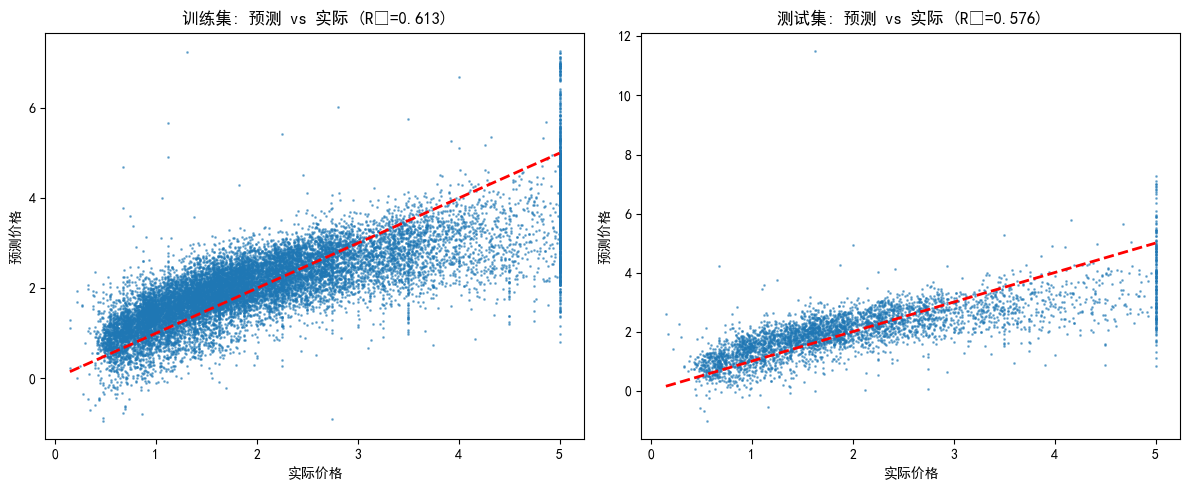

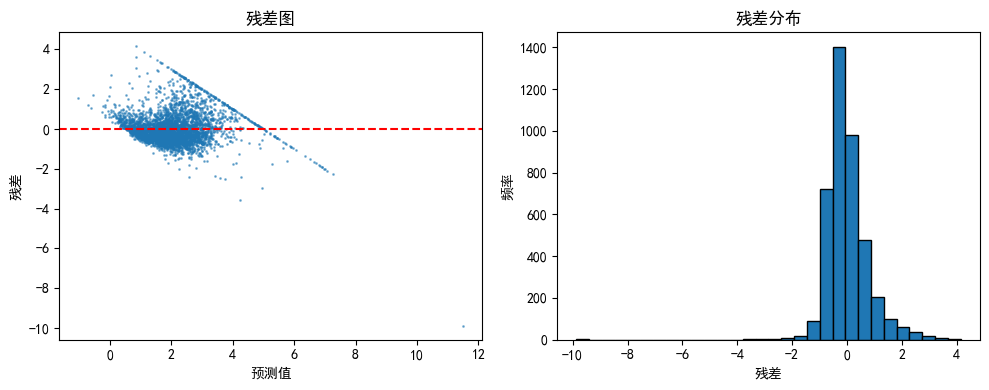

In [7]:
# 预测值 vs 实际值
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# 训练集
axes[0].scatter(y_train, y_train_pred, alpha=0.5, s=1)
axes[0].plot([y_train.min(), y_train.max()], 
             [y_train.min(), y_train.max()], 
             'r--', lw=2)
axes[0].set_xlabel('实际价格')
axes[0].set_ylabel('预测价格')
axes[0].set_title(f'训练集: 预测 vs 实际 (R²={r2_train:.3f})')

# 测试集
axes[1].scatter(y_test, y_test_pred, alpha=0.5, s=1)
axes[1].plot([y_test.min(), y_test.max()], 
             [y_test.min(), y_test.max()], 
             'r--', lw=2)
axes[1].set_xlabel('实际价格')
axes[1].set_ylabel('预测价格')
axes[1].set_title(f'测试集: 预测 vs 实际 (R²={r2_test:.3f})')

plt.tight_layout()
plt.show()

# 残差分析
residuals = y_test - y_test_pred
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.scatter(y_test_pred, residuals, alpha=0.5, s=1)
plt.axhline(y=0, color='r', linestyle='--')
plt.xlabel('预测值')
plt.ylabel('残差')
plt.title('残差图')

plt.subplot(1, 2, 2)
plt.hist(residuals, bins=30, edgecolor='black')
plt.xlabel('残差')
plt.ylabel('频率')
plt.title('残差分布')

plt.tight_layout()
plt.show()

In [8]:
# 线性回归的数学公式
print("\n=== 线性回归原理 ===")
print("线性回归假设目标变量与特征之间存在线性关系：")
print("y = w₁x₁ + w₂x₂ + ... + wₙxₙ + b")
print("\n其中：")
print("- y: 预测的目标变量（房价）")
print("- xᵢ: 第i个特征")
print("- wᵢ: 第i个特征的权重（系数）")
print("- b: 偏置项（截距）")
print("\n训练目标：最小化损失函数（MSE）")
print("MSE = (1/n) Σ(y_true - y_pred)²")

# 特征重要性
feature_importance = pd.DataFrame({
    'feature': housing.feature_names,
    'coefficient': model.coef_
})
feature_importance = feature_importance.reindex(
    feature_importance['coefficient'].abs().sort_values(ascending=False).index
)

print("\n=== 特征重要性（按系数绝对值排序）===")
print(feature_importance)


=== 线性回归原理 ===
线性回归假设目标变量与特征之间存在线性关系：
y = w₁x₁ + w₂x₂ + ... + wₙxₙ + b

其中：
- y: 预测的目标变量（房价）
- xᵢ: 第i个特征
- wᵢ: 第i个特征的权重（系数）
- b: 偏置项（截距）

训练目标：最小化损失函数（MSE）
MSE = (1/n) Σ(y_true - y_pred)²

=== 特征重要性（按系数绝对值排序）===
      feature  coefficient
6    Latitude    -0.896929
7   Longitude    -0.869842
0      MedInc     0.854383
3   AveBedrms     0.339259
2    AveRooms    -0.294410
1    HouseAge     0.122546
5    AveOccup    -0.040829
4  Population    -0.002308


In [9]:
print("\n=== 可能的改进方向 ===")
print("1. 多项式特征：添加特征的交互项或平方项")
print("2. 正则化：使用 Ridge 或 Lasso 回归减少过拟合")
print("3. 特征选择：删除不重要的特征")
print("4. 处理异常值：使用统计方法检测并处理")
print("5. 交叉验证：使用K折交叉验证获得更稳定的评估")


=== 可能的改进方向 ===
1. 多项式特征：添加特征的交互项或平方项
2. 正则化：使用 Ridge 或 Lasso 回归减少过拟合
3. 特征选择：删除不重要的特征
4. 处理异常值：使用统计方法检测并处理
5. 交叉验证：使用K折交叉验证获得更稳定的评估
